In [1]:
import numpy as np
import scipy

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 15, "text.usetex": True,
    "font.family": "Times New Roman"})
matplotlib.rcParams.update({"xtick.direction":"in", "xtick.top":True})
matplotlib.rcParams.update({"ytick.direction":"in", "ytick.right":True})
plt.rcParams['text.latex.preamble'] = r'\usepackage{xcolor}'

from os import path
import sys
sys.path.insert(1, '/home/jaeukk/30_Codes/python')
sys.path.insert(1, '/home/jaeukk/30_Codes/python/Common/')
import UsefulFunct as uf
import drawings as dr

def latex_float(f, significant_figure = 2):
    spec = "{0:1."+"{0:d}".format(significant_figure)+"e}"
    float_str = spec.format(f)#"{0:.2g}".format(f)
    if "e" in float_str:
        base, exponent = float_str.split("e")
        exponent = int(exponent)
        if exponent == 0:
            return r"{0}".format(base, int(exponent))
        elif exponent == 1:
            return r"{0} \times 10".format(base, int(exponent))
        else:
            return r"{0} \times 10^{{{1}}}".format(base, int(exponent))
    else:
        return float_str
  
dir=""

from Lloyd import lloyd_relaxation, modified_lloyd_relaxation


# Test1

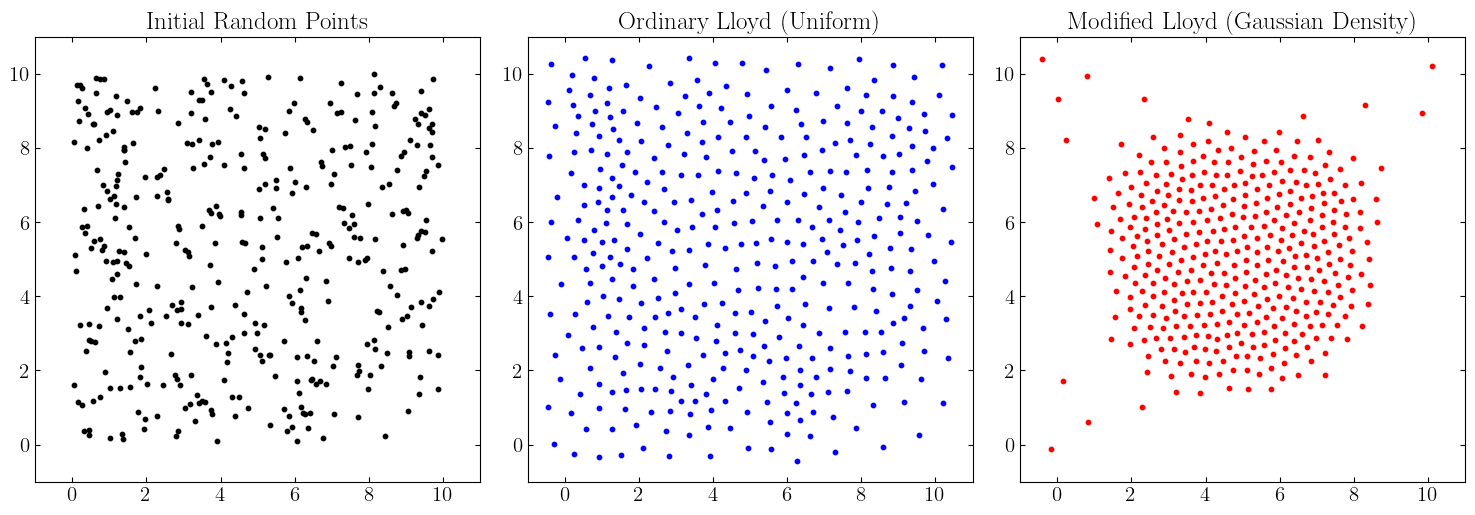

In [2]:

# Parameters
N = 400
bounds = (0, 10, 0, 10)
np.random.seed(42)
initial_points = np.random.uniform(0, 10, (N, 2))

# 1. Ordinary Lloyd Relaxation
points_ordinary = lloyd_relaxation(initial_points, bounds, alpha=0.2, iterations=20)

# 2. Modified Lloyd Relaxation with Density Function (2D Gaussian)
def rho_gaussian(x, y):
    return np.exp(-((x - 5)**2 + (y - 5)**2) / 1.0)
#    return 10*np.sin(x/2)**2 # np.exp(-((x - 5)**2 + (y - 5)**2) / 10.0)

points_modified = modified_lloyd_relaxation(initial_points, bounds, rho=rho_gaussian, alpha=0.2, iterations=100, samp_pts=200)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(initial_points[:, 0], initial_points[:, 1], c='k', s=10)
axes[0].set_title("Initial Random Points")

axes[1].scatter(points_ordinary[:, 0], points_ordinary[:, 1], c='b', s=10)
axes[1].set_title("Ordinary Lloyd (Uniform)")

axes[2].scatter(points_modified[:, 0], points_modified[:, 1], c='r', s=10)
axes[2].set_title("Modified Lloyd (Gaussian Density)")

for ax in axes:
    ax.set_xlim(-1, 11)
    ax.set_ylim(-1, 11)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [6]:
def rgb2gray(rgb):
    """
    Convert an RGB image to grayscale using the luminosity method.
    
    Args:
        rgb (numpy.ndarray): Input RGB image of shape (H, W, 3).
        
    Returns:
        numpy.ndarray: Grayscale image of shape (H, W).
    """
    return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])

# Test: modified Lloyd for a grayscale image

In [7]:
def rejection_sampling(density_func, num_points, bounds, seed):
    """
    Places random points accepted with probability proportional to the density function.
    """
    np.random.seed(seed)
    points = []
    xmin, xmax, ymin, ymax = bounds

    while len(points) < num_points:
        # Assuming domain [0, 10]x[0, 10] based on notebook context
        x = np.random.uniform(xmin, xmax)
        y = np.random.uniform(ymin, ymax)
        
        prob = density_func(x, y)
        if np.random.random() < prob:
            points.append([x, y])
            
    return np.array(points)


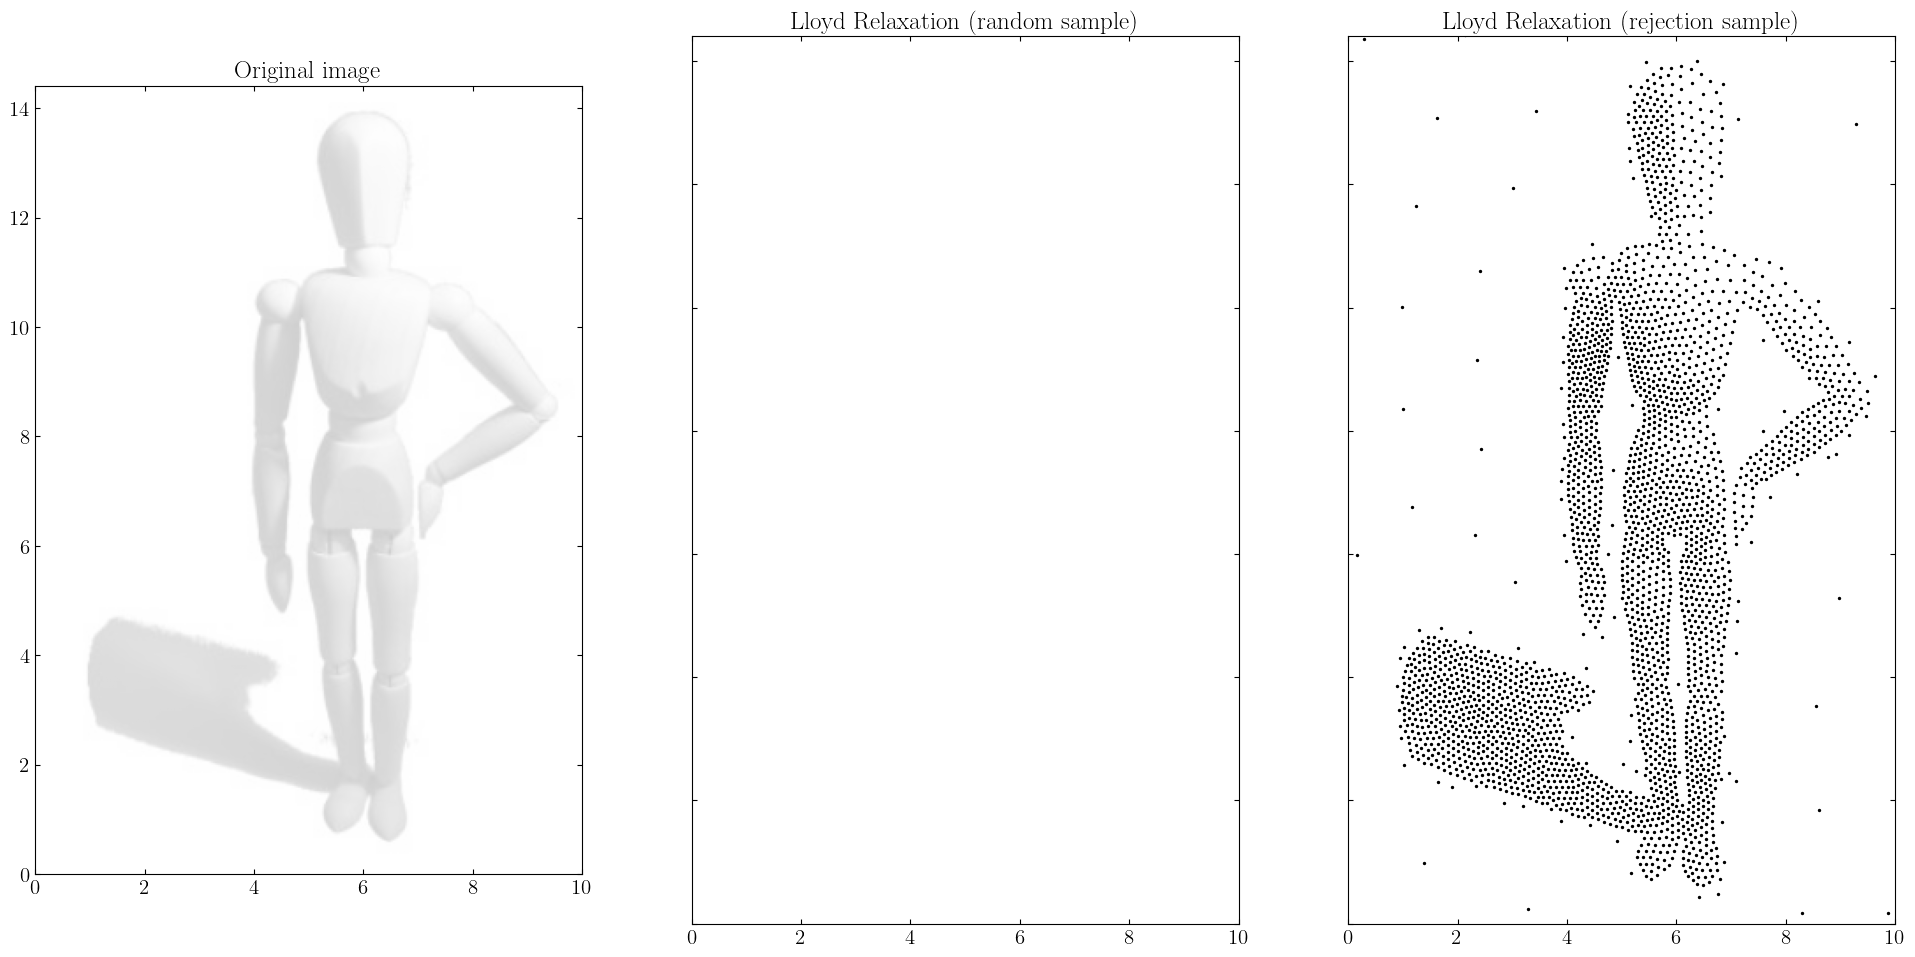

In [7]:
from scipy.interpolate import RegularGridInterpolator

# 1. Import a grayscale image
img_path = './data/ex6_gray.png'
img = plt.imread(img_path)

# If the image is RGB, convert it to grayscale using the function from cell 3
if img.ndim == 3:
    img_gray = rgb2gray(img)
else:
    img_gray = img

# Normalize image to [0, 1] and invert so that dark areas have higher density
img_gray = img_gray.astype(float)
img_gray = (img_gray - np.min(img_gray)) / (np.max(img_gray) - np.min(img_gray))
density_map = 1 - img_gray

# 2. Convert it into a local density function using interpolation
h, w = density_map.shape
x_coords = np.linspace(0, 10, w)
y_max = 10 * h / w
y_coords = np.linspace(0, y_max, h)
# Note: RegularGridInterpolator expects (y, x) for (row, col) indexing
interp_func = RegularGridInterpolator((y_coords, x_coords), np.flipud(density_map), bounds_error=False, fill_value=0)

def rho_image(x, y):
    # RegularGridInterpolator expects points as (N, 2) array of (y, x)
    pts = np.column_stack((y, x))
    return interp_func(pts)

N_pts = 3000
bounds = (0, 10, 0, y_max)

# 3. Random sampling
np.random.seed(42)
initial_pts = np.random.uniform(0, 10, (N_pts, 2))
points_img1 = modified_lloyd_relaxation(initial_pts, bounds, rho=rho_image, alpha=1., iterations=100, samp_pts=200)

# 4. Rejection sampling
initial_pts = rejection_sampling(rho_image, N_pts, bounds, 42)
points_img2 = modified_lloyd_relaxation(initial_pts, bounds, rho=rho_image, alpha=1., iterations=100, samp_pts=200)




# Visualization
fig, ax = plt.subplots(1,3,figsize=(8*3, 8 * h / w), sharex=True, sharey=True)
ax[0].imshow(img_gray, extent=[0, 10, 0, y_max], origin='upper', cmap='gray', alpha=0.2)
ax[0].set_title("Original image")

ax[1].scatter(points_img1[:, 0], points_img1[:, 1], c='k', s=2)
ax[2].scatter(points_img2[:, 0], points_img2[:, 1], c='k', s=2)
ax[1].set_title("Lloyd Relaxation (random sample)")
ax[2].set_title("Lloyd Relaxation (rejection sample)")

ax[0].set_xlim(0, 10)
ax[0].set_ylim(0, y_max)
ax[0].set_aspect('equal')
plt.show()

# Color stippling

In [2]:
%load_ext autoreload
%autoreload 2
import Stippling as st

In [4]:
# 1. Load a configuration
image_path = "./data/color1_1.png"
sample = st.BaseStipple(image_path, pixel_height=5, pixel_width=5)

# 2. Define color elements
color_map = {'r': (1, 0, 0), 'g': (0, 1, 0), 'b': (0, 0, 1)}
sample.set_color_map(color_map)

for v in color_map.keys():
    sample.create_hsv_interpolators(v)
    sample.create_density_interpolators()
sample.create_rgb_interpolators()

target colors are given in RGB system


In [5]:
sample.g_interp([1,100])

array([0.04313686])

## Brutal force idea

1. Turn a color image into a density function whose value is maximal at the white and minimal at the black.
2. Initial distribution: rejection sampling of the density function in step1.
3. Perform modified Lloyd algorithm using the density function in each subdomain of figure.
4. Color selection: sequentially determine color element of each sampling point by considering the local color and their neighboring points. (This step seems the most crucial part)


In [6]:
sample = st.BaseStipple(image_path, pixel_width=10.0, pixel_height=10.0)
width, height = sample.width, sample.height
print(f"Image dimensions: {width}x{height}")


Image dimensions: 1000.0x1000.0
